In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [10]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [11]:
grouped_df =df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [12]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

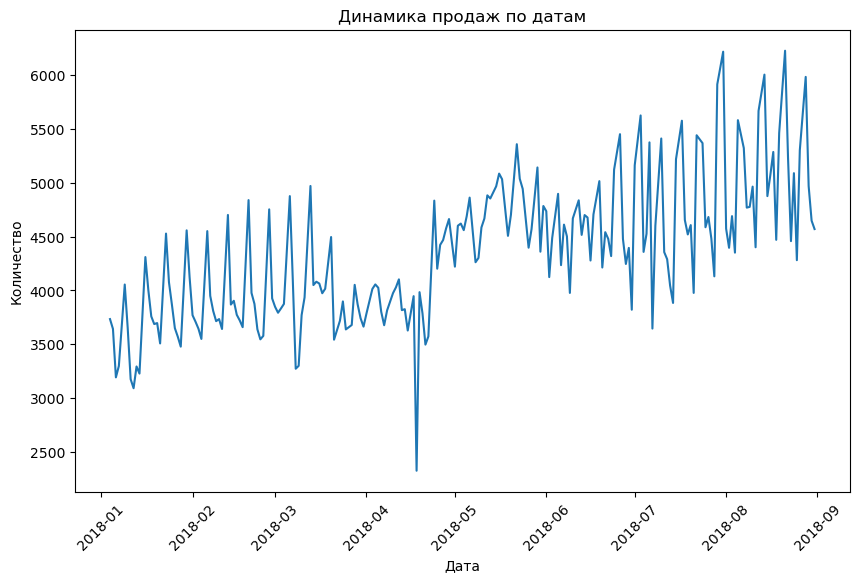

In [13]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_df, x='Дата', y='Количество')
plt.title('Динамика продаж по датам')
plt.xticks(rotation=45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [19]:
#На представленном графике отображена динамика продаж за период с января по сентябрь 2018 года.
#Можно выделить следующие ключевые особенности:
#Восходящий тренд: На протяжении всего периода наблюдается устойчивый рост объема продаж. Если в начале года (январь) значения колебались в районе 3500–4000 единиц,
#то к августу–сентябрю они достигли пиков в 6000+ единиц.
#Высокая волатильность: График имеет ярко выраженный «зубчатый» характер. Это говорит о сильных ежедневных колебаниях спроса или периодичности поставок (например, еженедельные циклы закупок).
#Аномальный спад: В середине апреля (2018-04) зафиксировано резкое падение продаж до локального минимума (ниже 2500 единиц).
#Это самая низкая точка на графике, которая может быть связана с техническим сбоем, праздниками или задержкой поставок.
#Сезонность: Видно, что амплитуда колебаний увеличивается к лету. Пиковые значения продаж становятся выше и достигаются чаще в период с июля по сентябрь.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [15]:
# Находим строку, где значение в столбце 'Количество' максимально
outlier_row = df[df['Количество'] == df['Количество'].max()]
outlier_row

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [16]:
# 1. Фильтруем по складу и месяцам (6, 7, 8)
# 2. Оставляем только среды (день недели в pandas: 2 — это среда, так как Пн=0)
summer_wednesdays = df[
    (df['Склад'] == 3) & 
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Дата'].dt.weekday == 2)
]

# 3. Группируем по товару и находим лидера по продажам
top_product = summer_wednesdays.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False).head(1)
print(top_product)

Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [17]:
import pandas as pd

# Читаем файл, пропуская первые 6 строк с описанием
# Если будут ошибки, попробуй поменять sep=';' на sep=','
weather = pd.read_csv('weather.csv', sep=';', skiprows=6, index_col=False)

# Названия столбцов в файлах rp5 обычно:
# 'Местное время в Астане' (столбец A) и 'T' (столбец B)
# Давай переименуем их для удобства
weather = weather.rename(columns={weather.columns[0]: 'Дата_время', weather.columns[1]: 'T'})

# Превращаем в формат даты
weather['Дата_время'] = pd.to_datetime(weather['Дата_время'], dayfirst=True)
weather['Дата'] = weather['Дата_время'].dt.date

# Группируем по дням и считаем СРЕДНЮЮ температуру (T)
daily_weather = weather.groupby('Дата')['T'].mean().reset_index()

# Обязательно переводим дату в datetime для объединения с продажами
daily_weather['Дата'] = pd.to_datetime(daily_weather['Дата'])

print("Данные по погоде готовы!")
print(daily_weather.head())


Данные по погоде готовы!
        Дата        T
0 2018-01-01  -9.4625
1 2018-01-02  -9.5125
2 2018-01-03 -11.4625
3 2018-01-04 -14.0750
4 2018-01-05 -16.8625


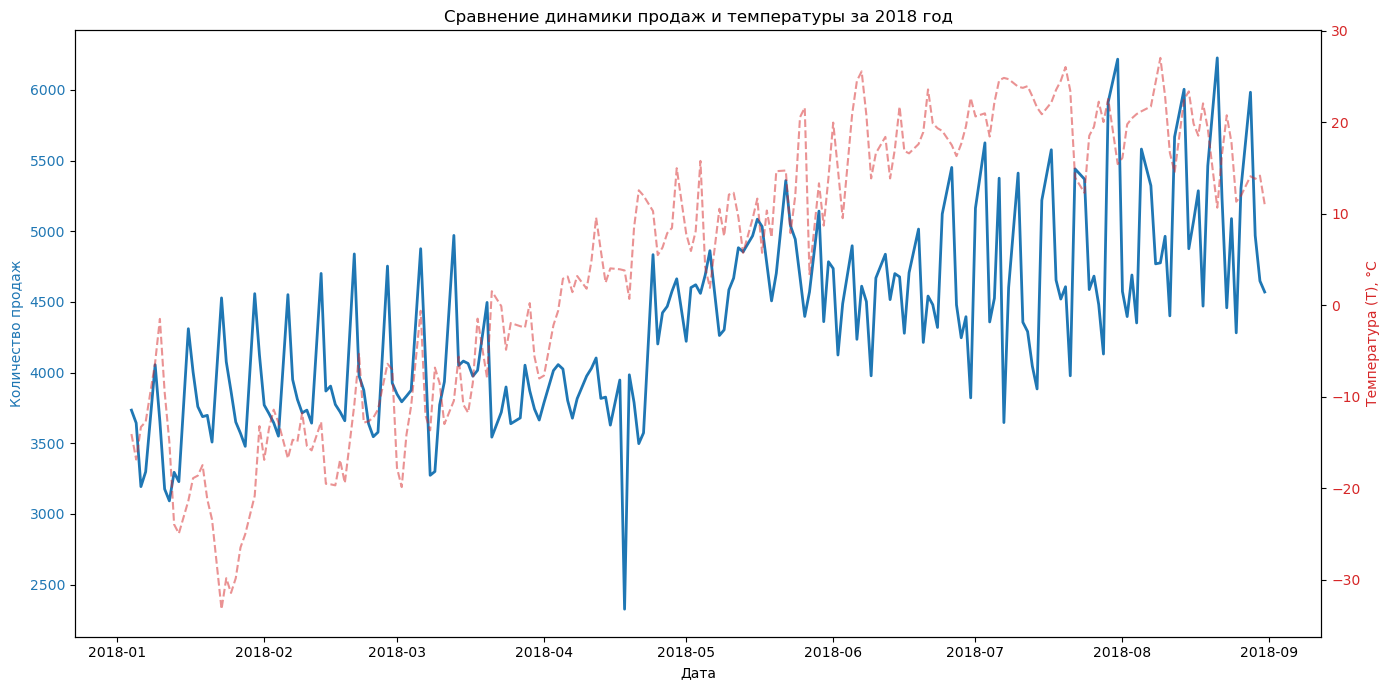

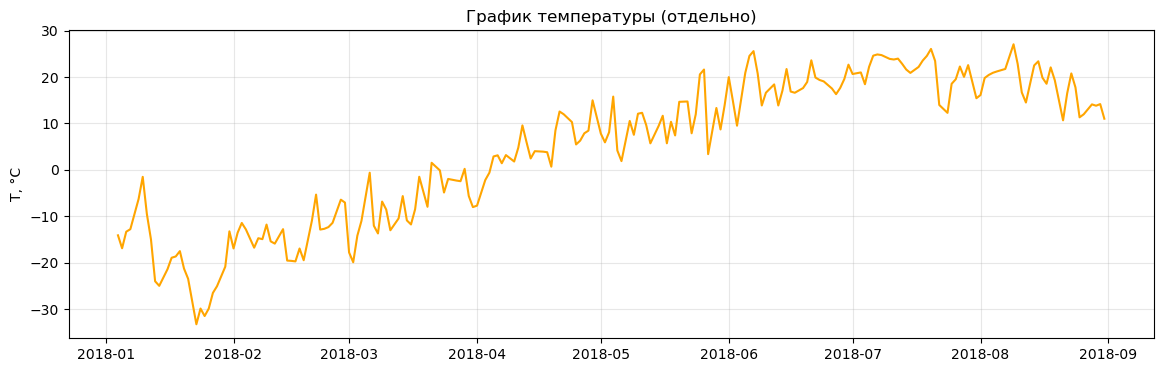

In [18]:
# 1. Объединяем данные
# grouped_df — продажи, daily_weather — погода
final_df = pd.merge(grouped_df, daily_weather, on='Дата', how='inner')

# 2. Рисуем совмещенный график
fig, ax1 = plt.subplots(figsize=(14, 7))

# Линия продаж (синяя)
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='tab:blue')
ax1.plot(final_df['Дата'], final_df['Количество'], color='tab:blue', label='Продажи', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Создаем вторую ось для температуры
ax2 = ax1.twinx() 
ax2.set_ylabel('Температура (T), °C', color='tab:red')
ax2.plot(final_df['Дата'], final_df['T'], color='tab:red', label='Температура', alpha=0.5, linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Сравнение динамики продаж и температуры за 2018 год')
fig.tight_layout()
plt.show()

# 3. Отдельный график температуры
plt.figure(figsize=(14, 4))
plt.plot(final_df['Дата'], final_df['T'], color='orange')
plt.title('График температуры (отдельно)')
plt.ylabel('T, °C')
plt.grid(True, alpha=0.3)
plt.show()
